In [141]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp                         # pour utiliser sympy, on lui donne l'alias sp
from IPython.display import *              # pour utiliser display qui formate les équations
sp.init_printing(use_latex=True)           # pour utiliser LaTeX, formattage de grande qualité 
%matplotlib inline

In [142]:
#
# définition des variables symboliques, ici on utilise la simplification qui est faite
# dans la section 2.3 et dans la section 2.4 ou P est modifié avec la gravité
# de sorte que la pression effective devient p+rho G L ou p-rho g L .
#
y,delta_y,L,W,rho,P0,PL,mu,B,v0=sp.symbols('y,delta_y,L,W,rho,P_0,P_L,mu,B,v_0')
vx=sp.Function('v_x')(y)

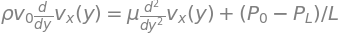

In [143]:
eq1=sp.Eq(rho*v0*sp.diff(vx,y),(P0-PL)/L+mu*sp.diff(vx,y,y))
#eq1=sp.Eq(                    (P0-PL)/L+mu*sp.diff(vx,y,y),0)
display(eq1)

On insère ensuite la loi de Newton pour remplacer $\tau_{xz}$

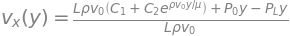

In [144]:
# La solution est faite avec la fonction dsolve de sympy
eq2=sp.dsolve(eq1,vx)
display(eq2.simplify())

>> Conditions aux limites,
>> en x = B, $v_z=0$

>> et en x=0, $v_z=0$


'profil de vitesse'

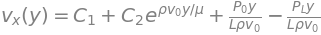

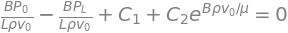

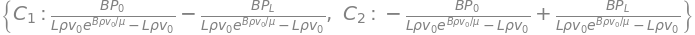

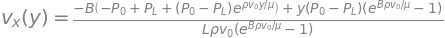

In [145]:
display('profil de vitesse',eq2)
eq3=sp.Eq(eq2.rhs.subs(x,B),0)
eq4=sp.Eq(eq2.rhs.subs(x,0),0)                   
display(eq3,eq4)
constantes=sp.solve((eq3,eq4),(C1,C2))
display(constantes)
vx=eq2.subs(constantes)
display(sp.simplify(vx))

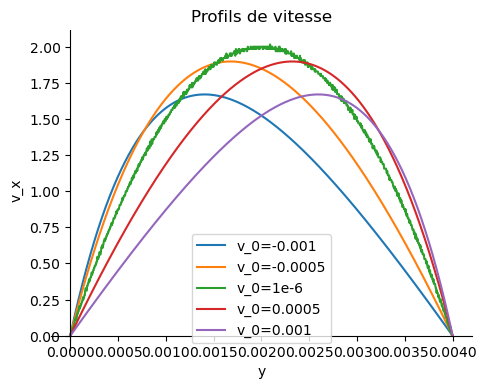

In [149]:
#
# Qu'on peut maintenant tracer, en donnant des valeurs numériques aux paramètres
# Attention, il faut réfléchir un peu et penser aux valeurs données...
#
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = 5,4
vxp=vx.subs(B,0.004).subs(P0,1000).subs(PL,0).subs(L,1).subs(mu,0.001).subs(rho,1000)
vxp1=vxp.subs(v0,-0.001)
vxp2=vxp.subs(v0,-0.0005)
vxp3=vxp.subs(v0,1e-10)
vxp4=vxp.subs(v0,0.0005)
vxp5=vxp.subs(v0,0.001)
p=sp.plot(vxp1.rhs.subs(dico),
        vxp2.rhs.subs(dico),
        vxp3.rhs.subs(dico),
        vxp4.rhs.subs(dico),
        vxp5.rhs.subs(dico),(y,0,B.subs(dico))
        ,title='Profils de vitesse',legend=True,
               xlabel='y',ylabel='v_x',show=False);
p[0].label='v_0=-0.001'
p[1].label='v_0=-0.0005'
p[2].label='v_0=1e-6'
p[3].label='v_0=0.0005'
p[4].label='v_0=0.001'
p.show()